In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("malaychand/coco-25-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'coco-25-classification-dataset' dataset.
Path to dataset files: /kaggle/input/coco-25-classification-dataset
Contents of base_path (/kaggle/input):
['coco-25-classification-dataset']
Contents of path (/kaggle/input/coco-25-classification-dataset):
['classification']


In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'classification', 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'classification', 'test'))}")

Contents of the 'train' directory: ['motorcycle', 'airplane', 'horse', 'bus', 'truck', 'dog', 'stop sign', 'cup', 'bird', 'car', 'elephant', 'potted plant', 'traffic light', 'cow', 'bicycle', 'chair', 'pizza', 'bench', 'bowl', 'cat', 'bottle', 'cake', 'couch', 'train', 'person']
Contents of the 'test' directory: ['motorcycle', 'airplane', 'horse', 'bus', 'truck', 'dog', 'stop sign', 'cup', 'bird', 'car', 'elephant', 'potted plant', 'traffic light', 'cow', 'bicycle', 'chair', 'pizza', 'bench', 'bowl', 'cat', 'bottle', 'cake', 'couch', 'train', 'person']



--- Sample Images from Training Dataset (/kaggle/input/coco-25-classification-dataset/classification/train) ---
Found 5250 images in /kaggle/input/coco-25-classification-dataset/classification/train. Displaying 6 samples:


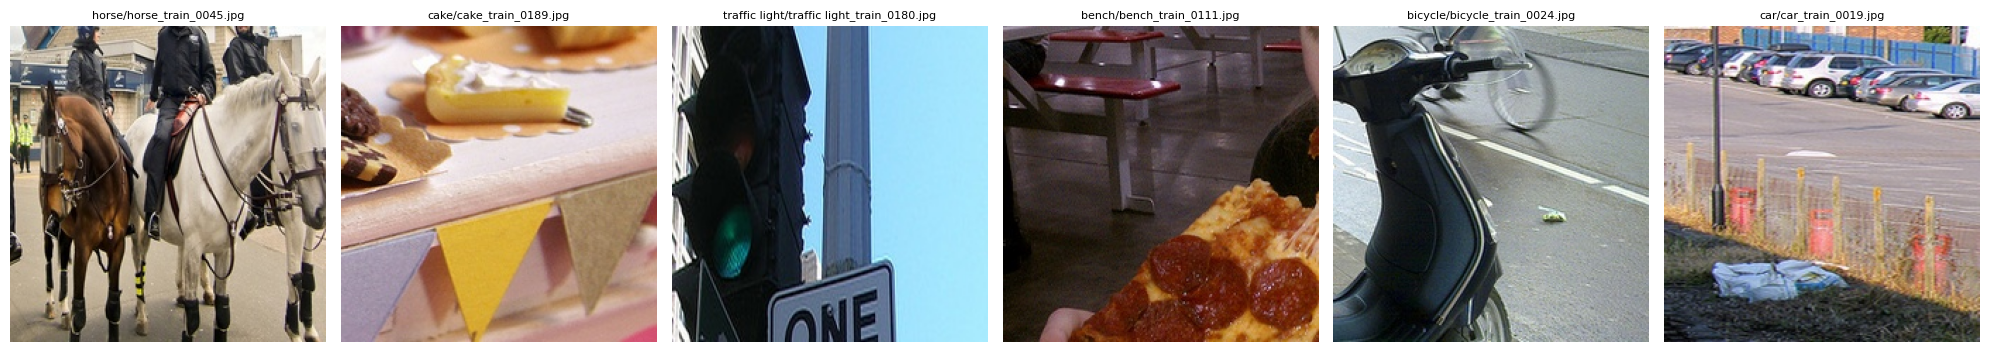


--- Sample Images from Test Dataset (/kaggle/input/coco-25-classification-dataset/classification/test) ---
Found 750 images in /kaggle/input/coco-25-classification-dataset/classification/test. Displaying 6 samples:


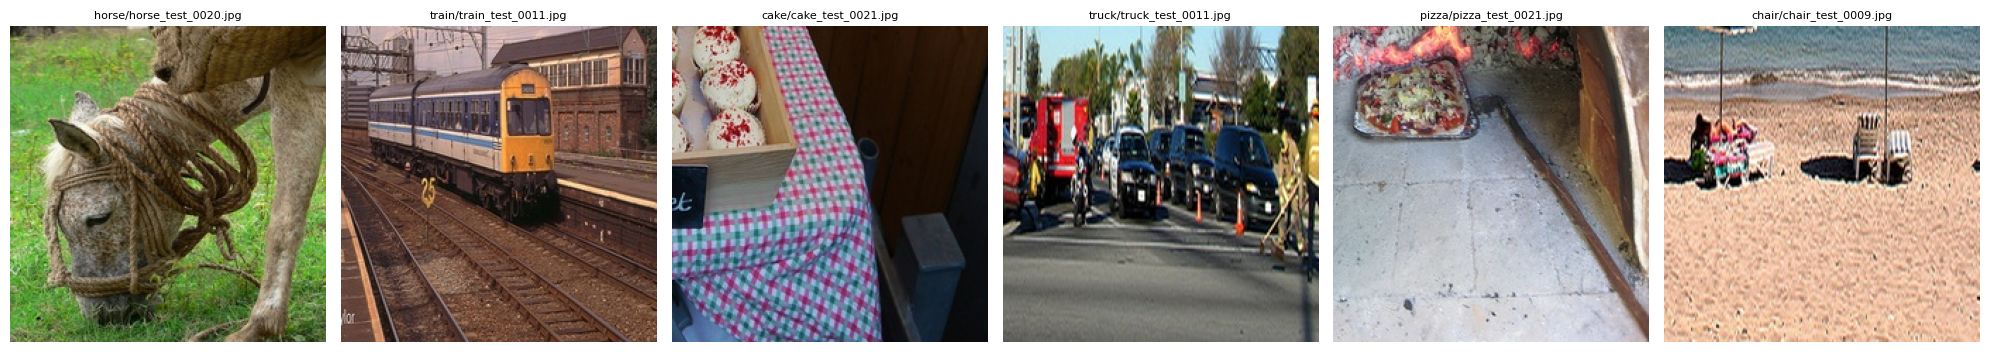

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to include 'classification' subdirectory
train_path = os.path.join(path, 'classification', 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

test_path = os.path.join(path, 'classification', 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda
Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [ ]:
# Define transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load datasets
image_datasets = {
    'train': datasets.ImageFolder(train_path, data_transforms['train']),
    'test': datasets.ImageFolder(test_path, data_transforms['test'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=2),
    'test': DataLoader(image_datasets['test'], batch_size=32, shuffle=False, num_workers=2)
}

# Build ResNet model
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
# The dataset has 25 classes
model.fc = nn.Linear(num_ftrs, 25)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
num_epochs = 10
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(num_epochs):
    for phase in ['train', 'test']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(image_datasets[phase])
        epoch_acc = running_corrects.double() / len(image_datasets[phase])

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())

        print(f'Epoch {epoch}/{num_epochs - 1} | {phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


Epoch 0/9 | train Loss: 1.9757 Acc: 0.4160
Epoch 0/9 | test Loss: 2.9210 Acc: 0.3013
Epoch 1/9 | train Loss: 1.3204 Acc: 0.6076
Epoch 1/9 | test Loss: 1.6889 Acc: 0.5240
Epoch 2/9 | train Loss: 0.9336 Acc: 0.7175
Epoch 2/9 | test Loss: 1.2698 Acc: 0.6480
Epoch 3/9 | train Loss: 0.7790 Acc: 0.7650
Epoch 3/9 | test Loss: 1.4242 Acc: 0.6400
Epoch 4/9 | train Loss: 0.5842 Acc: 0.8160
Epoch 4/9 | test Loss: 1.0508 Acc: 0.7067
Epoch 5/9 | train Loss: 0.4726 Acc: 0.8585
Epoch 5/9 | test Loss: 1.2562 Acc: 0.7067
Epoch 6/9 | train Loss: 0.3802 Acc: 0.8861
Epoch 6/9 | test Loss: 1.1173 Acc: 0.7427
Epoch 7/9 | train Loss: 0.3023 Acc: 0.9069
Epoch 7/9 | test Loss: 1.1051 Acc: 0.7613
Epoch 8/9 | train Loss: 0.2662 Acc: 0.9164
Epoch 8/9 | test Loss: 1.0509 Acc: 0.7587
Epoch 9/9 | train Loss: 0.1701 Acc: 0.9522
Epoch 9/9 | test Loss: 1.1948 Acc: 0.7613


In [ ]:
# Summarize Results
print("--- Training Summary ---")
final_train_acc = history['train_acc'][-1]
final_test_acc = history['test_acc'][-1]
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.4f}")

--- Training Summary ---
Final Training Accuracy: 0.9522
Final Test Accuracy: 0.7613


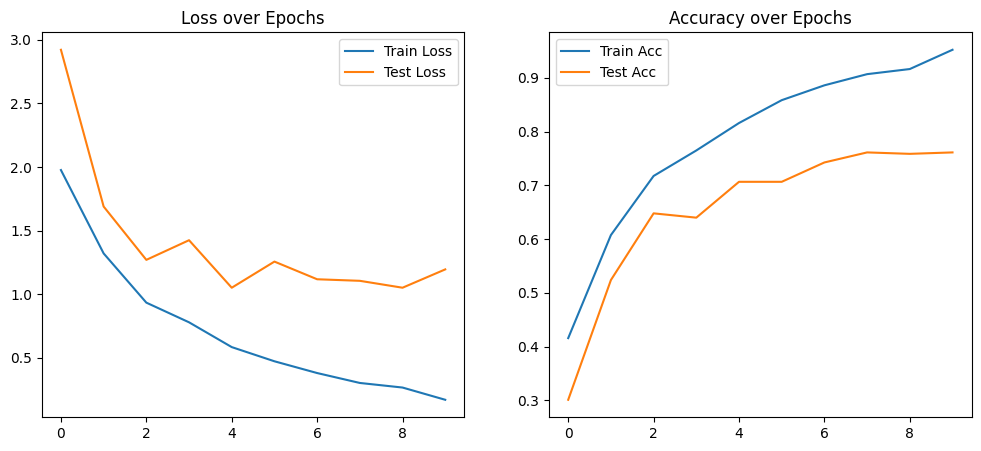

In [ ]:
# Display Training Charts
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()